# Plot microstructure profiles

In [265]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), r"../../scripts/functions/figures")))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), r"../../scripts/functions/general_functions")))
from general_functions import read_netCDF_xr, read_matfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.io.matlab import mat_struct

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'  # or any installed font


### Specify if using Renku or not:

In [266]:
using_Renku = False

In [267]:
if using_Renku:
    datafolder=os.path.join('..','..','..','data-lakezug')   
else:
    datafolder=os.path.join('..','..','data')
    # For interactive plots in Jupyter Notebook 
    %matplotlib widget     

### Parameters

Specify the path to the data folder and the date of the campaign:

In [286]:
campaign_name='20251127'
datalevel='Level2'
instrument='VMP' # 'VMP' or 'microCTD'
fileprof=['VMP003_down_prof1'] # List of profile names (without level and extension) 
matstring='down5.0_K5.3_L_NAS0.0058_singlepole_nfft3_EPFL_Goodman' # Name of folders where .mat files are stored
savefig=False # Set to True to save the figure 

# Relative path:
data_folder_rel=os.path.join(datafolder,instrument,campaign_name,datalevel)

In [287]:
# Another option if to specify the list of variables to plos as for the CTD profiles:
# varnames_oneprof=["Temp","Cond","sat","Turb","pH","SALIN","rho"]

Set the plot colors:

In [288]:
colplot=plt.get_cmap('tab10',len(fileprof))
white_color_fraction=0.6
whitecol=np.array([1,1,1,1])

### Load the data

netCDF files

In [289]:
dataprof=[]
for kf in range(len(fileprof)):
    if datalevel=='Level1':
        filename_full='L1_'+fileprof[kf]+'.nc'
    elif datalevel=='Level2':
        filename_full='L2_'+fileprof[kf]+'.nc'
    else:
        raise Exception('Wrong level')
        
    dataprof.append(read_netCDF_xr(os.path.join(data_folder_rel,filename_full)))

mat files

In [290]:
datamat=[]
for kf,file in enumerate(fileprof):
    matfolder=file[:file.find('_')]+'_'+matstring
    #matfiles=[f for f in os.listdir(os.path.join(data_folder_rel,matfolder)) if f.endswith(".mat")]
    if datalevel=='Level1':
        matfile='L1_'+file[:file.find('_prof')]+'.mat'
    elif datalevel=='Level2':
        matfile='L2_'+file[:file.find('_prof')]+'.mat'
    else:
        raise Exception('Wrong level')
    
    datamat.append(read_matfile(os.path.join(data_folder_rel,matfolder,matfile)))

### 1. Figure with profile data

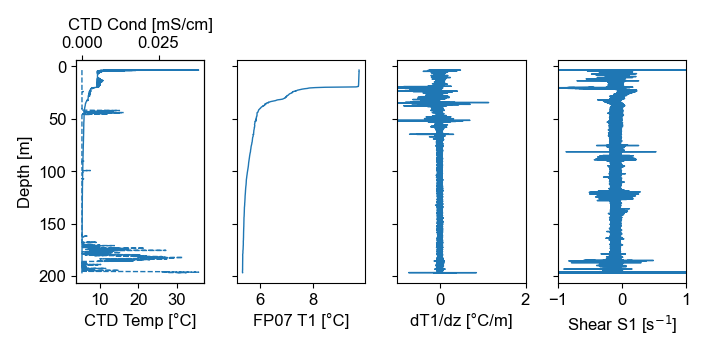

In [291]:
# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


for kf in range(len(dataprof)):
    ax[0].plot(dataprof[kf].SLOW_temperature,dataprof[kf].SLOW_depth,linewidth=1,color=colplot(kf))
    ax0b = ax[0].twiny()
    ax0b.plot(dataprof[kf].SLOW_conductivity/1000,dataprof[kf].SLOW_depth,linewidth=1,linestyle='--',color=colplot(kf))
    
    ax[1].plot(dataprof[kf].FAST_fast_T1.data,dataprof[kf].FAST_depth,linewidth=1,color=colplot(kf))
    
    ax[2].plot(dataprof[kf].FAST_grad_T1.data+2*kf,dataprof[kf].FAST_depth,linewidth=1,color=colplot(kf))
    
    ax[3].plot(dataprof[kf].FAST_fast_S1.data+kf,dataprof[kf].FAST_depth,linewidth=1,color=colplot(kf))


# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('CTD Temp [°C]')
ax0b.set_xlabel('CTD Cond [mS/cm]')
ax[1].set_xlabel('FP07 T1 [°C]')
ax[2].set_xlabel('dT1/dz [°C/m]')
ax[3].set_xlabel('Shear S1 [s$^{-1}$]')

ax[2].set_xlim(-1,2*len(dataprof))
ax[3].set_xlim(-1,len(dataprof))
ax[0].invert_yaxis()

fig.set_tight_layout(True)

Save the figure

In [292]:

if savefig:
    fig.savefig(os.path.join("Figures_turbulence","prof_"+campaign_name+".png"),dpi=400)

### 2. Figures quality control

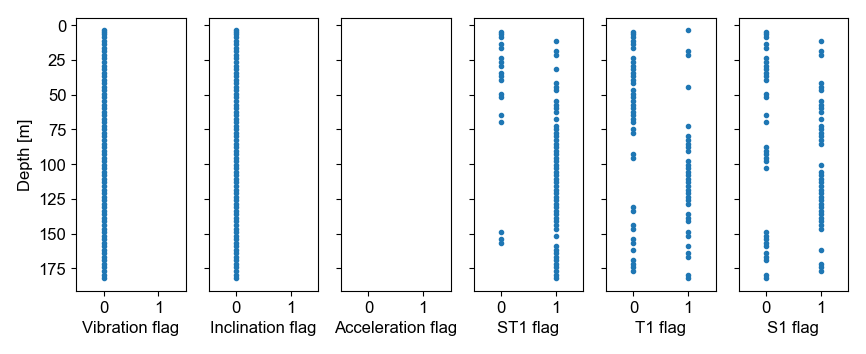

In [293]:
# Figure with flags
fig,ax = plt.subplots(1,6,figsize=(22 / 2.54, 9 / 2.54),sharey=True,sharex=True)  # Convert from cm to inches

for kf in range(len(dataprof)):

    ax[0].plot(datamat[kf]['BINNED']["flag_vibration"],datamat[kf]['BINNED']["depth"],'.',color=colplot(kf))

    ax[1].plot(datamat[kf]['BINNED']["flag_inclination"],datamat[kf]['BINNED']["depth"],'.',color=colplot(kf))

    ax[2].plot(datamat[kf]['BINNED']["flag_acceleration"],datamat[kf]['BINNED']["depth"],'.',color=colplot(kf))

    if "flag_ST1" in datamat[kf]['BINNED'].keys():
        ax[3].plot(datamat[kf]['BINNED']["flag_ST1"],datamat[kf]['BINNED']["depth"],'.',color=colplot(kf))

    if "flag_T1" in datamat[kf]['BINNED'].keys():
        ax[4].plot(datamat[kf]['BINNED']["flag_T1"],datamat[kf]['BINNED']["depth"],'.',color=colplot(kf))

    if "flag_S1" in datamat[kf]['BINNED'].keys():
        ax[5].plot(datamat[kf]['BINNED']["flag_S1"],datamat[kf]['BINNED']["depth"],'.',color=colplot(kf))

ax[0].set_xlim(-0.5,1.5)
ax[0].invert_yaxis()
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('Vibration flag')
ax[1].set_xlabel('Inclination flag')
ax[2].set_xlabel('Acceleration flag')
ax[3].set_xlabel('ST1 flag')
ax[4].set_xlabel('T1 flag')
ax[5].set_xlabel('S1 flag')

fig.set_tight_layout(True)

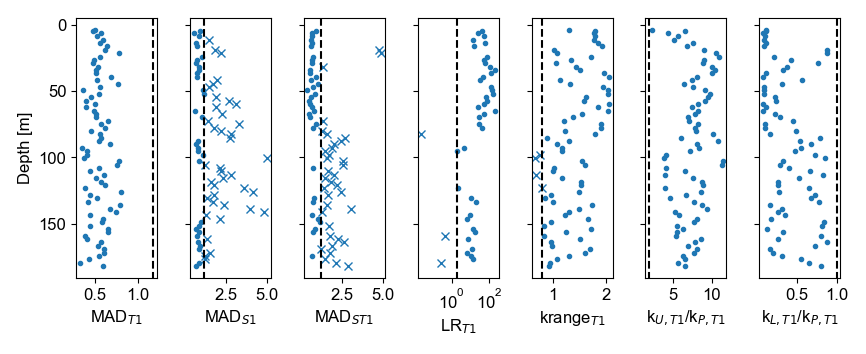

In [294]:
MAD_t=2*np.nanmean(datamat[kf]['BINNED']["MADc"])
LR_t=2
krange_t=0.8
kUkP_t=2
kLkP_t=1



# Figure with quality metrics
fig,ax = plt.subplots(1,7,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

for kf in range(len(dataprof)):

    if "MAD_T1" in datamat[kf]['BINNED'].keys():
        ax[0].plot(datamat[kf]['BINNED']["MAD_T1"][datamat[kf]['BINNED']["MAD_T1"]<MAD_t],datamat[kf]['BINNED']["depth"][datamat[kf]['BINNED']["MAD_T1"]<MAD_t],'.',color=colplot(kf))
        ax[0].plot(datamat[kf]['BINNED']["MAD_T1"][datamat[kf]['BINNED']["MAD_T1"]>MAD_t],datamat[kf]['BINNED']["depth"][datamat[kf]['BINNED']["MAD_T1"]>MAD_t],'x',color=colplot(kf))

    if "MAD_S1" in datamat[kf]['BINNED'].keys():
        ax[1].plot(datamat[kf]['BINNED']["MAD_S1"][datamat[kf]['BINNED']["MAD_S1"]<MAD_t],datamat[kf]['BINNED']["depth"][datamat[kf]['BINNED']["MAD_S1"]<MAD_t],'.',color=colplot(kf))
        ax[1].plot(datamat[kf]['BINNED']["MAD_S1"][datamat[kf]['BINNED']["MAD_S1"]>MAD_t],datamat[kf]['BINNED']["depth"][datamat[kf]['BINNED']["MAD_S1"]>MAD_t],'x',color=colplot(kf))

    if "MAD_ST1" in datamat[kf]['BINNED'].keys():
        ax[2].plot(datamat[kf]['BINNED']["MAD_ST1"][datamat[kf]['BINNED']["MAD_ST1"]<MAD_t],datamat[kf]['BINNED']["depth"][datamat[kf]['BINNED']["MAD_ST1"]<MAD_t],'.',color=colplot(kf))
        ax[2].plot(datamat[kf]['BINNED']["MAD_ST1"][datamat[kf]['BINNED']["MAD_ST1"]>MAD_t],datamat[kf]['BINNED']["depth"][datamat[kf]['BINNED']["MAD_ST1"]>MAD_t],'x',color=colplot(kf))

    if "LR_T1" in datamat[kf]['BINNED'].keys():
        ax[3].plot(datamat[kf]['BINNED']["LR_T1"][datamat[kf]['BINNED']["LR_T1"]>LR_t],datamat[kf]['BINNED']["depth"][datamat[kf]['BINNED']["LR_T1"]>LR_t],'.',color=colplot(kf))
        ax[3].plot(datamat[kf]['BINNED']["LR_T1"][datamat[kf]['BINNED']["LR_T1"]<LR_t],datamat[kf]['BINNED']["depth"][datamat[kf]['BINNED']["LR_T1"]<LR_t],'x',color=colplot(kf))

    if "krange_T1" in datamat[kf]['BINNED'].keys():
        ax[4].plot(datamat[kf]['BINNED']["krange_T1"][datamat[kf]['BINNED']["krange_T1"]>krange_t],datamat[kf]['BINNED']["depth"][datamat[kf]['BINNED']["krange_T1"]>krange_t],'.',color=colplot(kf))
        ax[4].plot(datamat[kf]['BINNED']["krange_T1"][datamat[kf]['BINNED']["krange_T1"]<krange_t],datamat[kf]['BINNED']["depth"][datamat[kf]['BINNED']["krange_T1"]<krange_t],'x',color=colplot(kf))

    if "kU_T1" in datamat[kf]['BINNED'].keys() and "kpeak_T1" in datamat[kf]['BINNED'].keys():
        kUkP=datamat[kf]['BINNED']["kU_T1"]/datamat[kf]['BINNED']["kpeak_T1"]
        ax[5].plot(kUkP[kUkP>kUkP_t],datamat[kf]['BINNED']["depth"][kUkP>kUkP_t],'.',color=colplot(kf))
        ax[5].plot(kUkP[kUkP<kUkP_t],datamat[kf]['BINNED']["depth"][kUkP<kUkP_t],'x',color=colplot(kf))
      
    if "kL_T1" in datamat[kf]['BINNED'].keys() and "kpeak_T1" in datamat[kf]['BINNED'].keys():
        kLkP=datamat[kf]['BINNED']["kL_T1"]/datamat[kf]['BINNED']["kpeak_T1"]
        ax[6].plot(kLkP[kLkP<kLkP_t],datamat[kf]['BINNED']["depth"][kLkP<kLkP_t],'.',color=colplot(kf))
        ax[6].plot(kLkP[kLkP>kLkP_t],datamat[kf]['BINNED']["depth"][kLkP>kLkP_t],'x',color=colplot(kf))

ylimval=ax[0].get_ylim()
ax[0].plot([MAD_t,MAD_t],ylimval,'--',color='k')
ax[1].plot([MAD_t,MAD_t],ylimval,'--',color='k')
ax[2].plot([MAD_t,MAD_t],ylimval,'--',color='k')
ax[3].plot([LR_t,LR_t],ylimval,'--',color='k')
ax[4].plot([krange_t,krange_t],ylimval,'--',color='k')
ax[5].plot([kUkP_t,kUkP_t],ylimval,'--',color='k')
ax[6].plot([kLkP_t,kLkP_t],ylimval,'--',color='k')

ax[0].set_ylim(ylimval)
ax[0].invert_yaxis()
ax[0].set_ylabel('Depth [m]')

ax[0].set_xlabel('MAD$_{T1}$')
ax[1].set_xlabel('MAD$_{S1}$')
ax[2].set_xlabel('MAD$_{ST1}$')
ax[3].set_xlabel('LR$_{T1}$')
ax[3].set_xscale('log')
ax[4].set_xlabel('krange$_{T1}$')
ax[5].set_xlabel('k$_{U,T1}$/k$_{P,T1}$')
ax[6].set_xlabel('k$_{L,T1}$/k$_{P,T1}$')

fig.set_tight_layout(True)

### 3. Figure with turbulence data

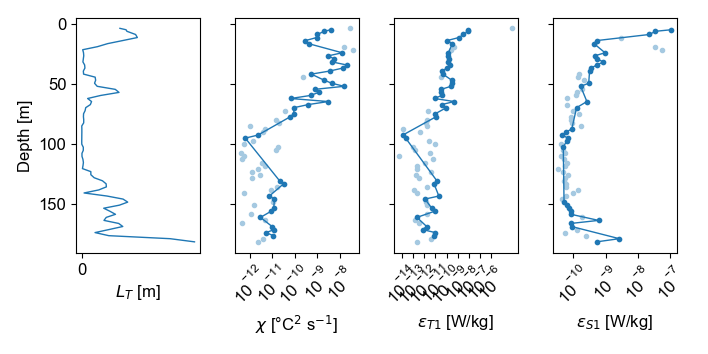

In [295]:
# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


for kf in range(len(dataprof)):
    pale_color = white_color_fraction * whitecol + (1-white_color_fraction) * np.array(colplot(kf))
    
    indkeep_T1=np.where(dataprof[kf].BINNED_flag_T1.data==0)[0]
    indkeep_S1=np.where(dataprof[kf].BINNED_flag_S1.data==0)[0]
    
    ax[0].plot(dataprof[kf].BINNED_LTuT1.data,dataprof[kf].BINNED_depth.data,'-',linewidth=1,color=colplot(kf))
    
    ax[1].plot(dataprof[kf].BINNED_Xi_T1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[1].plot(dataprof[kf].BINNED_Xi_T1.data[indkeep_T1],dataprof[kf].BINNED_depth.data[indkeep_T1],'.-',linewidth=1,color=colplot(kf))
    
    ax[2].plot(dataprof[kf].BINNED_eps_T1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[2].plot(dataprof[kf].BINNED_eps_T1.data[indkeep_T1],dataprof[kf].BINNED_depth.data[indkeep_T1],'.-',linewidth=1,color=colplot(kf))
    
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data[indkeep_S1],dataprof[kf].BINNED_depth.data[indkeep_S1],'.-',linewidth=1,color=colplot(kf))
    
    
# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('$L_T$ [m]')
ax[1].set_xlabel('$\\chi$ [°C$^2$ s$^{-1}$]')
ax[2].set_xlabel('$\\varepsilon_{T1}$ [W/kg]')
ax[3].set_xlabel('$\\varepsilon_{S1}$ [W/kg]')

xlimval=ax[0].get_xlim()
ax[0].set_xticks(np.arange(0, 100, 10))
ax[0].set_xlim(xlimval)

ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, -5, 1))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)

ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, -5, 1))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)

ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, -5, 1))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)

ax[0].invert_yaxis()

fig.set_tight_layout(True)


Save the figure:

In [248]:
if savefig:
    fig.savefig(os.path.join("Figures_turbulence","prof_turb_"+campaign_name+".png"),dpi=400)

### 3. Figure spectrum

In [308]:
indfile=0 # index of the netCDF file
depth_spec=125 # [m]
Tlimval=[1e-10,1e0]
Slimval=[1e-10,1e0]
MAD_t=2*np.nanmean(datamat[kf]['BINNED']["MADc"])

In [309]:
def get_spec_data(datamat,indfile,indprof,ind_bin,name_spec):
    if indprof==0 and type(datamat[indfile]['BINNED'])==dict:
        spec_data=datamat[indfile]['BINNED'][name_spec][ind_bin]
    elif type(datamat[indfile]['BINNED'])==list:
        spec_data=datamat[indfile]['BINNED'][indprof][name_spec][ind_bin]
    else:
        raise Exception('Wrong format for BINNED in mat file')
    return spec_data

In [310]:
def plot_specT(ax,specT,Tlimval,epsT,MAD,MADt,LR,flagval,kL,kU,name):
    ax.loglog(specT['k0'],specT['PSD_raw'],'-',color='black',label='Raw spectrum')
    ax.loglog(specT['k0'],specT['PSD0'],'-',color='C0',label='Corrected spectrum')
    ax.loglog(specT['k'][specT['ind_fit']],specT['PSD'][specT['ind_fit']],'o',color='C0',label='Spectrum for fitting')
    ax.loglog(specT['k0'],specT['Sn0'],':',color='k',label='Noise spectrum')
    ax.loglog(specT['k0'],specT['PSD_theo'],'-',color='red',label='Theoretical spectrum')
    ax.loglog(specT['k'][specT['ind_fit']],specT['Sm'][specT['ind_fit']]+specT['Sn'][specT['ind_fit']],':',color='red',linewidth=2,label='Power spectrum')

    ax.plot(specT['kn'],Tlimval[0],'^',color=[0.5,0.5,0.5],markersize=8,label='$k_n$')
    ax.text(specT['kn'],Tlimval[0],'$k_n$',color=[0.5,0.5,0.5],fontsize=8,va='top',ha='center')
    ax.plot(specT['kP'],Tlimval[0],'^',color='C0',markersize=8,label='$k_P$')
    ax.text(specT['kP'],Tlimval[0],'$k_P$',color='C0',fontsize=8,va='top',ha='center')
    ax.plot(specT['kSNR'],Tlimval[0],'^',color='k',markersize=8,label='$k_{SNR}$')
    ax.text(specT['kSNR'],Tlimval[0],'$k_{SNR}$',color='k',fontsize=8,va='top',ha='center')
    ax.plot(specT['kB'],Tlimval[0],'^',color='r',markersize=8,label='$k_B$')
    ax.text(specT['kB'],Tlimval[0],'$k_B$',color='r',fontsize=8,va='top',ha='center')
    ax.plot(specT['kH'],Tlimval[0],'^',color='w',markeredgecolor='k',markersize=8,label='$k_H$')
    ax.text(specT['kH'],Tlimval[0],'$k_H$',color='k',fontsize=8,va='top',ha='center')
    ax.plot([kL,kL],Slimval,'--',color='k')
    ax.text(kL,Slimval[1],'$k_L$',color='k',fontsize=8,va='bottom',ha='center')
    ax.plot([kU,kU],Slimval,'--',color='k')
    ax.text(kU,Slimval[1],'$k_U$',color='k',fontsize=8,va='bottom',ha='center')
    

    if flagval==0:
        text_eps='Good spectrum\n$\\varepsilon_{{{}}} $ = {:.1e} W/kg\nMAD = {:.1f} ({:.1f})\nLR = {:.1f} (2)'.format(name,epsT,MAD,MADt,LR)
        coltext=[0,0.6,0,1]
    elif flagval==1:
        text_eps='Bad spectrum\n$\\varepsilon_{{{}}} $ = {:.1e} W/kg\nMAD = {:.1f} ({:.1f})\nLR = {:.1f} (2)'.format(name,epsT,MAD,MADt,LR)
        coltext='red'
    
    ax.text(ax.get_xlim()[0],5*Tlimval[1],text_eps,color=coltext,fontsize=10,va='bottom',ha='left')
    ax.set_ylim(Tlimval[0],Tlimval[1])

def plot_specS(ax,specS,Slimval,epsS,MAD,MADt,flagval,kL,kU,name):
    ax.loglog(specS['k'],specS['PSD0'],'-',color='black',label='Corrected spectrum')
    ax.loglog(specS['k'],specS['PSD'],'-',color='C1',label='Corrected and denoised corrected')
    ax.loglog(specS['k'][specS['ind_fit']],specS['PSD'][specS['ind_fit']],'o',color='C1',label='Spectrum for fitting')
    ax.loglog(specS['k'],specS['PSD_theo'],'-',color='red',label='Theoretical spectrum')
    
    ax.plot(specS['kn'],Slimval[0],'^',color=[0.5,0.5,0.5],markersize=8,label='$k_n$')
    ax.text(specS['kn'],Slimval[0],'$k_n$',color=[0.5,0.5,0.5],fontsize=8,va='top',ha='center')
    ax.plot(specS['kK'],Slimval[0],'^',color='r',markersize=8,label='$k_K$')
    ax.text(specS['kK'],Slimval[0],'$k_K$',color='r',fontsize=8,va='top',ha='center')
    ax.plot(specS['k_lim'],Slimval[0],'^',color='w',markeredgecolor='k',markersize=8,label='$k_{lim}$')
    ax.text(specS['k_lim'],Slimval[0],'$k_{lim}$',color='k',fontsize=8,va='top',ha='center')
    ax.plot([kL,kL],Slimval,'--',color='k')
    ax.text(kL,Slimval[1],'$k_L$',color='k',fontsize=8,va='bottom',ha='center')
    ax.plot([kU,kU],Slimval,'--',color='k')
    ax.text(kU,Slimval[1],'$k_U$',color='k',fontsize=8,va='bottom',ha='center')

    if flagval==0:
        text_eps='Good spectrum\n$\\varepsilon_{{{}}} $ = {:.1e} W/kg\nMAD = {:.1f} ({:.1f})'.format(name,epsS,MAD,MADt)
        coltext=[0,0.6,0,1]
    elif flagval==1:
        text_eps='Bad spectrum\n$\\varepsilon_{{{}}} $ = {:.1e} W/kg\nMAD = {:.1f} ({:.1f})'.format(name,epsS,MAD,MADt)
        coltext='red'

    ax.text(ax.get_xlim()[0],5*Slimval[1],text_eps,color=coltext,fontsize=10,va='bottom',ha='left')
    ax.set_ylim(Slimval[0],Slimval[1])

In [311]:
ind_bin=np.where(dataprof[indfile].BINNED_depth.data>=depth_spec)[0][0]
depth_bin=dataprof[indfile].BINNED_depth.data[ind_bin]
indprof=int(fileprof[indfile][fileprof[indfile].find('_prof')+5:])-1
plot_specT1=False
plot_specT2=False
plot_specS1=False
plot_specS2=False
if 'SPECTRUMT1' in datamat[indfile]['BINNED'].keys():
    specT1=get_spec_data(datamat,indfile,indprof,ind_bin,'SPECTRUMT1')
    plot_specT1=True
if 'SPECTRUMT2' in datamat[indfile]['BINNED'].keys(): 
    specT2=get_spec_data(datamat,indfile,indprof,ind_bin,'SPECTRUMT2')
    plot_specT2=True
if 'SPECTRUMS1' in datamat[indfile]['BINNED'].keys(): 
    specS1=get_spec_data(datamat,indfile,indprof,ind_bin,'SPECTRUMS1')
    plot_specS1=True
if 'SPECTRUMS2' in datamat[indfile]['BINNED'].keys(): 
    specS2=get_spec_data(datamat,indfile,indprof,ind_bin,'SPECTRUMS2')
    plot_specS2=True

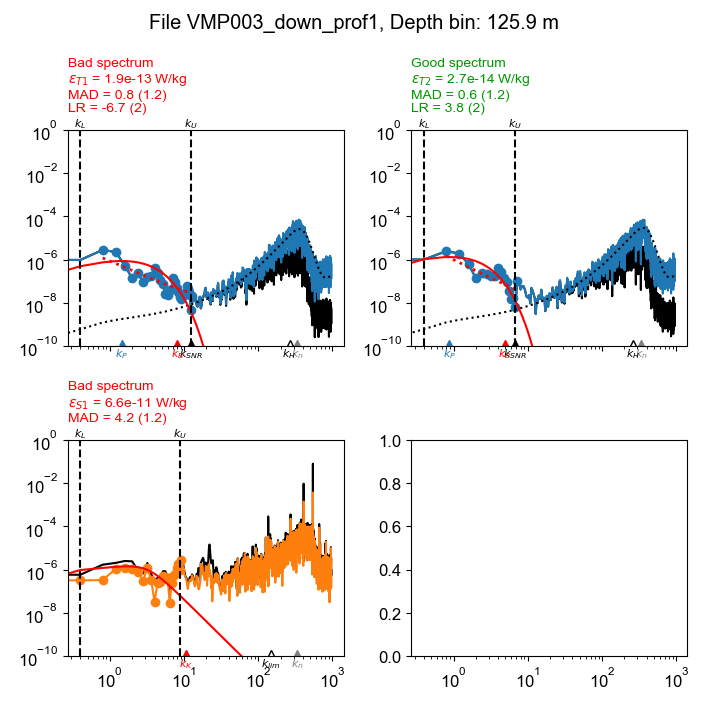

In [312]:
# Create a figure with specified size in centimeters
fig,ax = plt.subplots(2,2,figsize=(18 / 2.54, 18 / 2.54),sharex=True)  # Convert from cm to inches

# Temperature spectrum:
if plot_specT1:
    plot_specT(ax[0,0],specT1,Tlimval,epsT=dataprof[indfile].BINNED_eps_T1.data[ind_bin],MAD=datamat[indfile]['BINNED']["MAD_T1"][ind_bin],MADt=MAD_t,
               LR=datamat[indfile]['BINNED']["LR_T1"][ind_bin],flagval=datamat[indfile]['BINNED']["flag_T1"][ind_bin],kL=datamat[indfile]['BINNED']["kL_T1"][ind_bin],kU=datamat[indfile]['BINNED']["kU_T1"][ind_bin],name='T1')
    
if plot_specT2:
    plot_specT(ax[0,1],specT2,Tlimval,epsT=dataprof[indfile].BINNED_eps_T2.data[ind_bin],MAD=datamat[indfile]['BINNED']["MAD_T2"][ind_bin],MADt=MAD_t,
               LR=datamat[indfile]['BINNED']["LR_T2"][ind_bin],flagval=datamat[indfile]['BINNED']["flag_T2"][ind_bin],kL=datamat[indfile]['BINNED']["kL_T2"][ind_bin],kU=datamat[indfile]['BINNED']["kU_T2"][ind_bin],name='T2')

# Shear spectrum:
if plot_specS1:
    plot_specS(ax[1,0],specS1,Slimval,epsS=dataprof[indfile].BINNED_eps_S1.data[ind_bin],MAD=datamat[indfile]['BINNED']["MAD_S1"][ind_bin],MADt=MAD_t,
               flagval=datamat[indfile]['BINNED']["flag_S1"][ind_bin],kL=datamat[indfile]['BINNED']["kL_S1"][ind_bin],kU=datamat[indfile]['BINNED']["kU_S1"][ind_bin],name='S1') 

if plot_specS2:
    plot_specS(ax[1,1],specS2,Slimval,epsS=dataprof[indfile].BINNED_eps_S2.data[ind_bin],MAD=datamat[indfile]['BINNED']["MAD_S2"][ind_bin],MADt=MAD_t,
               flagval=datamat[indfile]['BINNED']["flag_S2"][ind_bin],kL=datamat[indfile]['BINNED']["kL_S2"][ind_bin],kU=datamat[indfile]['BINNED']["kU_S2"][ind_bin],name='S2')

fig.suptitle('File '+fileprof[indfile]+', Depth bin: '+str(round(depth_bin*10)/10)+' m')

fig.set_tight_layout(True)


In [313]:
savefig=True
if savefig:
    fig.savefig(os.path.join("Figures_turbulence","spec_"+campaign_name+"_prof_"+
                             fileprof[indfile]+"_binsize_"+str(dataprof[indfile].info_dpD)+"_depth_{:.1f}m.png".format(depth_bin)),dpi=400)